# 2. Defining the model grid

**What this shows:** how to place, rotate and size an XBeach grid with `RegularGrid`,
and how to check it is oriented correctly.

**Prerequisites:** [1. Your first XBeach model](01_first_model.ipynb).

**You will learn:**

- how `GeoPoint` handles coordinates in different reference systems
- what `ori`, `alfa`, `dx`, `dy`, `nx`, `ny` and `crs` mean
- the XBeach orientation convention: offshore boundary, origin and axes
- how to inspect grid geometry and extend a grid

**Data used:** none.

## Setup

In [1]:
import matplotlib.pyplot as plt
from rompy_xbeach.grid import GeoPoint, RegularGrid

## 1. Points with a coordinate reference system

A `GeoPoint` is a coordinate pair plus its CRS. It can be reprojected, so you can give
the grid origin in whatever system your data uses.

In [2]:
origin = GeoPoint(x=115.594239, y=-32.641104, crs=4326)
origin_mga = origin.reproject(28350)
print(f"WGS84:        x={origin.x:.6f}, y={origin.y:.6f}")
print(f"MGA zone 50:  x={origin_mga.x:.1f}, y={origin_mga.y:.1f}")

WGS84:        x=115.594239, y=-32.641104
MGA zone 50:  x=368145.0, y=6387626.6


## 2. The grid definition

XBeach uses a rectilinear grid whose x-axis runs **cross-shore, from the offshore
boundary towards land**:

![XBeach grid scheme](xbeach_grid_scheme.png)

*Adapted from the
[XBeach manual](https://xbeach.readthedocs.io/en/latest/xbeach_manual.html#grid-set-up).*

| Field | Meaning |
|---|---|
| `ori` | Origin, the corner of the grid on the offshore boundary |
| `alfa` | Angle of the x-axis, degrees counter-clockwise from east |
| `dx`, `dy` | Cell size along x (cross-shore) and y (alongshore), in `crs` units |
| `nx`, `ny` | Number of grid points along x and y |
| `crs` | Projected CRS the grid is built in (metres) |

On this west-facing coast the x-axis must point roughly east, so `alfa=347` rotates it
13° clockwise from east.

In [3]:
grid = RegularGrid(
    ori=origin,
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)
grid

RegularGrid(ori=GeoPoint(x=115.594239, y=-32.641104, crs='EPSG:4326'), alfa=347.0, dx=10.0, dy=15.0, nx=230, ny=220, crs='EPSG:28350')

## 3. Checking the orientation

`plot()` marks the origin (red dot) and the offshore boundary (red line). The
offshore boundary must face the open sea.

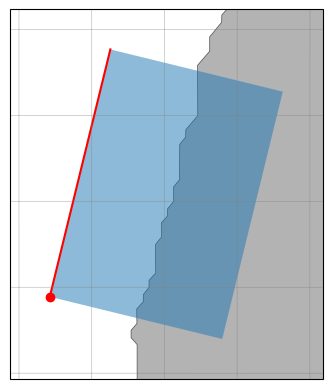

In [4]:
ax = grid.plot(scale="f")

Each side of the grid has a name used by XBeach boundary conditions: `front` is
offshore, `back` is landward, and `left` and `right` are the lateral sides.

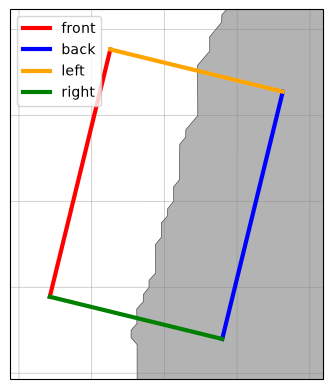

In [5]:
ax = grid.plot(
    scale="f", grid_kwargs={"facecolor": "none"}, show_origin=False, show_offshore=False
)
for side, colour in [
    ("front", "red"),
    ("back", "blue"),
    ("left", "orange"),
    ("right", "green"),
]:
    ax.plot(
        *getattr(grid, side),
        color=colour,
        linewidth=3,
        transform=grid.transform,
        label=side,
    )
ax.legend(loc="upper left")

### A common mistake

Putting the origin on the landward side, with the axis flipped, gives a grid that
covers the same area but has its offshore boundary on land. XBeach would force waves
from the beach.

Text(0.5, 1.0, 'Wrong: offshore boundary on land')

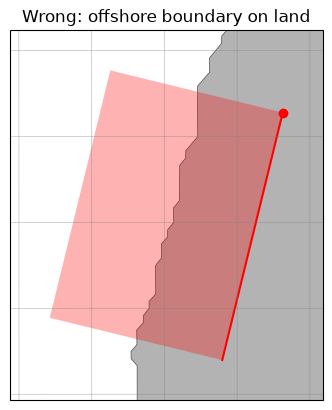

In [6]:
wrong = RegularGrid(
    ori=GeoPoint(x=grid.x[-1, -1], y=grid.y[-1, -1], crs=grid.crs),
    alfa=grid.alfa - 180,
    dx=grid.dx,
    dy=grid.dy,
    nx=grid.nx,
    ny=grid.ny,
    crs=grid.crs,
)
ax = wrong.plot(scale="f", grid_kwargs={"facecolor": "red", "alpha": 0.3, "zorder": 2})
ax.set_title("Wrong: offshore boundary on land")

## 4. Grid geometry

The grid exposes its geometry for plotting and for selecting forcing data. Forcing
is usually taken at the `centre` of the grid or at the middle of the `offshore`
boundary.

In [7]:
print(f"Origin in grid CRS: x0={grid.x0:.1f}, y0={grid.y0:.1f}")
print(f"Shape (ny, nx):     {grid.shape}")
print(f"Grid centre:        {grid.centre}")
print(f"Offshore midpoint:  {grid.offshore}")
print(f"Coordinate arrays:  x {grid.x.shape}, y {grid.y.shape}")

Origin in grid CRS: x0=368145.0, y0=6387626.6
Shape (ny, nx):     (220, 230)
Grid centre:        (369630.13818098354, 6388969.42314107)
Offshore midpoint:  (368514.48445680446, 6389226.992098292)
Coordinate arrays:  x (220, 230), y (220, 230)


## 5. The XBeach parameters

These are the values the grid contributes to `params.txt`. XBeach counts cells, so its
`nx` and `ny` are one less than the number of grid points, and `vardx=0` tells XBeach
the grid has constant spacing.

In [8]:
for key, value in grid.params.items():
    print(f"{key} = {value}")

vardx = 0
nx = 229
ny = 219
dx = 10.0
dy = 15.0
xori = 368145.00235004467
yori = 6387626.589266883
alfa = 347.0
projection = +proj=utm +zone=50 +south +ellps=GRS80 +units=m +no_defs +type=crs


## 6. Extending a grid

`expand()` adds cells on any side. The bathymetry class uses it to extend the domain
offshore and laterally (see [Tutorial 3](03_bathymetry.ipynb)).

Original: 230 x 220 points
Extended: 260 x 240 points


Text(0.5, 1.0, 'Original (dark) and extended (gold) grid')

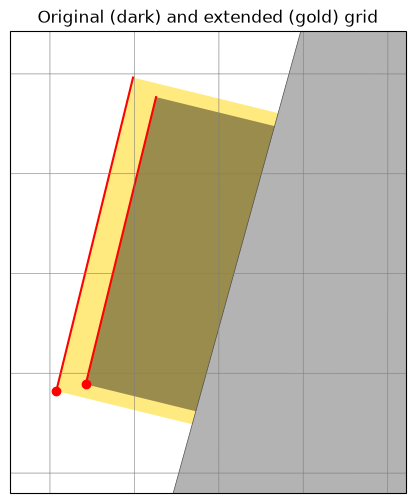

In [9]:
extended = grid.expand(front=30, left=10, right=10)
print(f"Original: {grid.nx} x {grid.ny} points")
print(f"Extended: {extended.nx} x {extended.ny} points")

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": grid.projection})
extended.plot(ax=ax, scale="i", grid_kwargs={"facecolor": "gold", "alpha": 0.5})
grid.plot(ax=ax, grid_kwargs={"facecolor": "black", "alpha": 0.4}, set_extent=False)
ax.set_title("Original (dark) and extended (gold) grid")

## Summary

- The grid origin sits on the offshore boundary, and the x-axis points towards land.
- `alfa` is measured counter-clockwise from east.
- Always plot a new grid and check that the red offshore boundary faces the sea.

**Next:** [3. Bathymetry from your data](03_bathymetry.ipynb).

**See also:** [Grid plotting and export](../examples/grid_plotting_and_export.ipynb)
covers coastline options, projections and saving grids to KML or GeoJSON.